# Pythia Checkpoints

## Save model weights

In [ ]:
from helpers import save_pythia_checkpoint_summary, list_pythia_eval_steps
from helpers import list_pythia_eval_steps

models = ['pythia-1.4b-deduped', 'pythia-2.8b-deduped', 'pythia-6.9b-deduped', 'pythia-12b-deduped']
steps = [143000]

for model in models:
    for step in steps:
        save_pythia_checkpoint_summary(
            model,
            step,
        )

c:\Users\s4531973\Documents\PhD\Code\logdeterminant\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\s4531973\Documents\PhD\Code\logdeterminant\pythia-1.4b-deduped\step143000\models--EleutherAI--pythia-1.4b-deduped. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 2

## HTMP

### Load ESDFit

In [ ]:
import esdfit as esdfit
import torch
import numpy as np
from importlib import reload; reload(esdfit)
from helpers import list_pythia_eval_steps

# Load fits
model = "pythia-1b-deduped"
steps = list_pythia_eval_steps(model)[12:]
fit = esdfit.ESDFit(model=model, 
                    dataset='pile', 
                    kernel='weight', 
                    batch_size='2m', 
                    subsample=False, 
                    file_dir = 'data/htmp/epoch',
                    weight_type='QueryKey',
                    layer=0)
fit.load_htmp_fit()

True

### Fit HTMP

In [31]:
fit.fit_htmp(search_method='grid', 
             shared_beta_grid=False, 
             beta_from_tau=False,
             n_eval=200,
             kappa_min=0.1, 
             kappa_max=4, 
             num_kappas=20, 
             kappa_log_scale=False,
             beta_min=0.1, 
             beta_max = 4, 
             num_betas = 20, 
             beta_log_scale=False,
             tau_min=0,
             tau_max=0,
             num_taus=1,
             epochs_list=None,
             moment_penalty_weight=0.5,
             verbose=True,
             extra_verbose=True,
             shared_tau_grid=False,
             stieltjes=False,
             vectorized_grid=True,
             save_fit=True)

Loading eigenvalues...
Fitting HTMP parameters for 15 epochs using grid search...
Best grid point: kappa=0.9211, beta=1.537, distance=0.154902
Fitting HTMP for Epoch: 3000, κ*: 0.921, β*: 1.537, τ*: 0.197, ||.||ₚ*: 0.155
Best grid point: kappa=0.7158, beta=0.9211, distance=0.0904134
Fitting HTMP for Epoch: 13000, κ*: 0.716, β*: 0.921, τ*: 0.176, ||.||ₚ*: 0.090
Best grid point: kappa=0.7158, beta=0.5105, distance=0.0866398
Fitting HTMP for Epoch: 23000, κ*: 0.716, β*: 0.511, τ*: 0.195, ||.||ₚ*: 0.087
Best grid point: kappa=0.7158, beta=0.5105, distance=0.0571964
Fitting HTMP for Epoch: 33000, κ*: 0.716, β*: 0.511, τ*: 0.157, ||.||ₚ*: 0.057
Best grid point: kappa=0.9211, beta=0.5105, distance=0.0898639
Fitting HTMP for Epoch: 43000, κ*: 0.921, β*: 0.511, τ*: 0.125, ||.||ₚ*: 0.090
Best grid point: kappa=0.9211, beta=0.5105, distance=0.078946
Fitting HTMP for Epoch: 53000, κ*: 0.921, β*: 0.511, τ*: 0.110, ||.||ₚ*: 0.079
Best grid point: kappa=0.9211, beta=0.5105, distance=0.0896063
Fitting

### Fit by hand

1it [00:00,  1.40it/s]


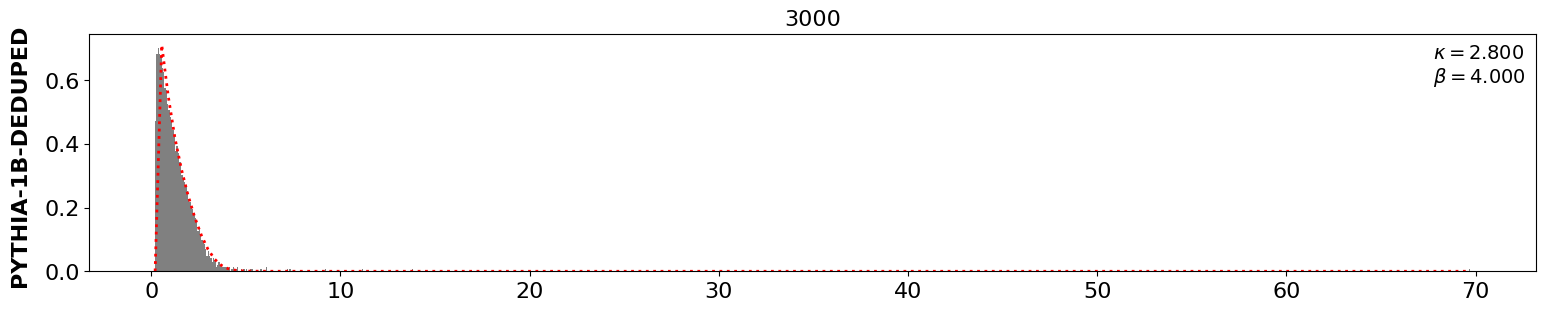

In [191]:
fit.kappa_opt[3000] = 2.8
fit.beta_opt[3000] = 4
fit.plot_esd(epoch_plot_interval=1, epochs_list=[3000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  2.31it/s]


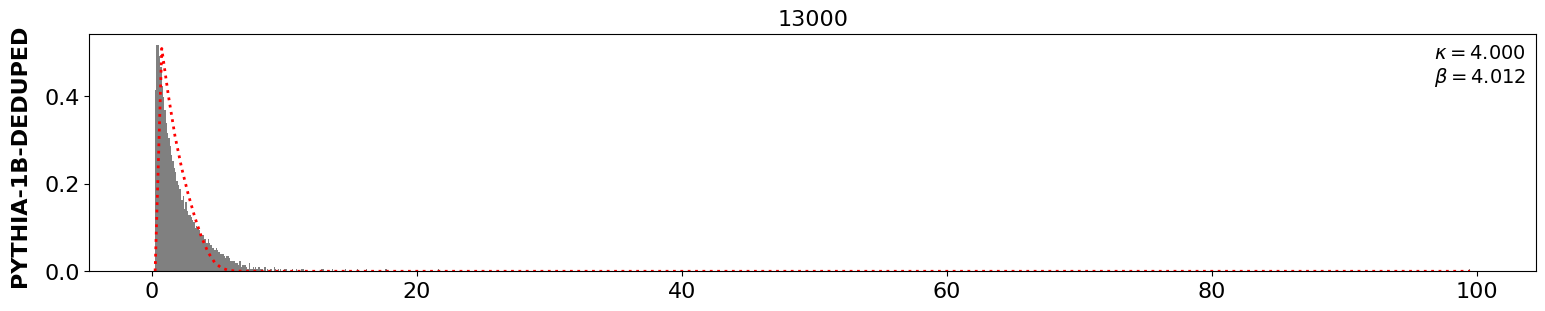

In [11]:
fit.kappa_opt[13000] = 4
fit.beta_opt[13000] = 1 / fit.tau_opt[13000]
fit.plot_esd(epoch_plot_interval=1, epochs_list=[13000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

In [7]:
fit.kappa_opt[13000]
fit.beta_opt[13000]

2.3

1it [00:00,  2.09it/s]


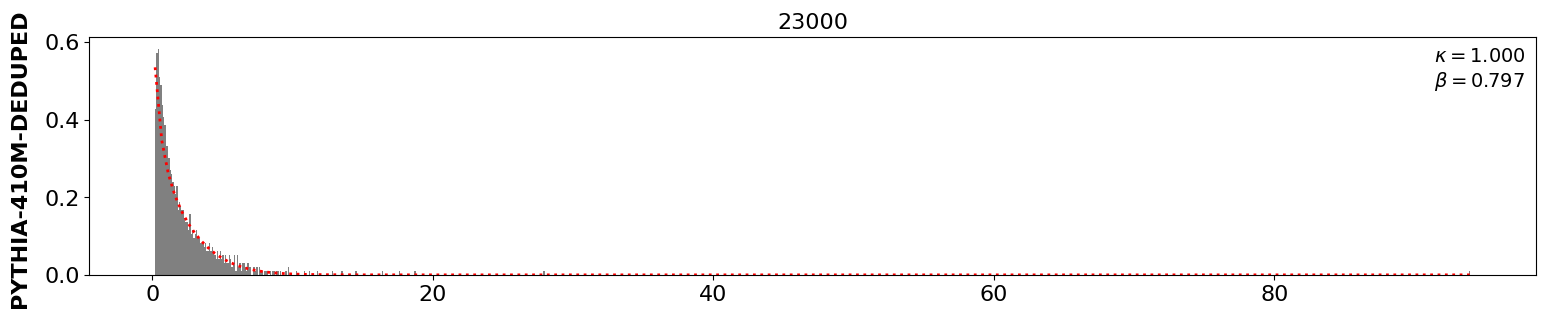

In [6]:
fit.kappa_opt[23000] = 1
fit.beta_opt[23000] = 0.1 / fit.tau_opt[43000] #0.8
fit.plot_esd(epoch_plot_interval=1, epochs_list=[23000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  3.08it/s]


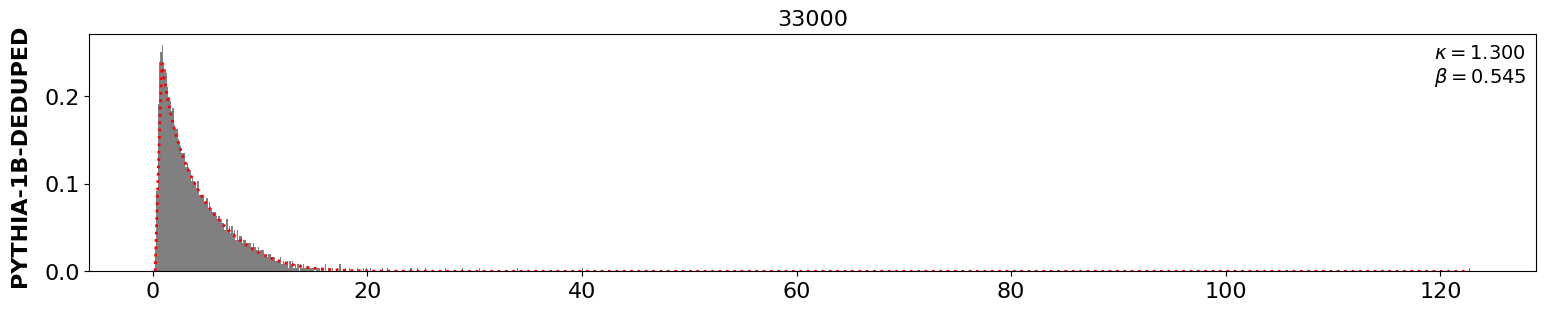

In [194]:
fit.kappa_opt[33000] = 1.3
fit.beta_opt[33000] = 0.1 / fit.tau_opt[43000] #0.75
fit.plot_esd(epoch_plot_interval=1, epochs_list=[33000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  2.20it/s]


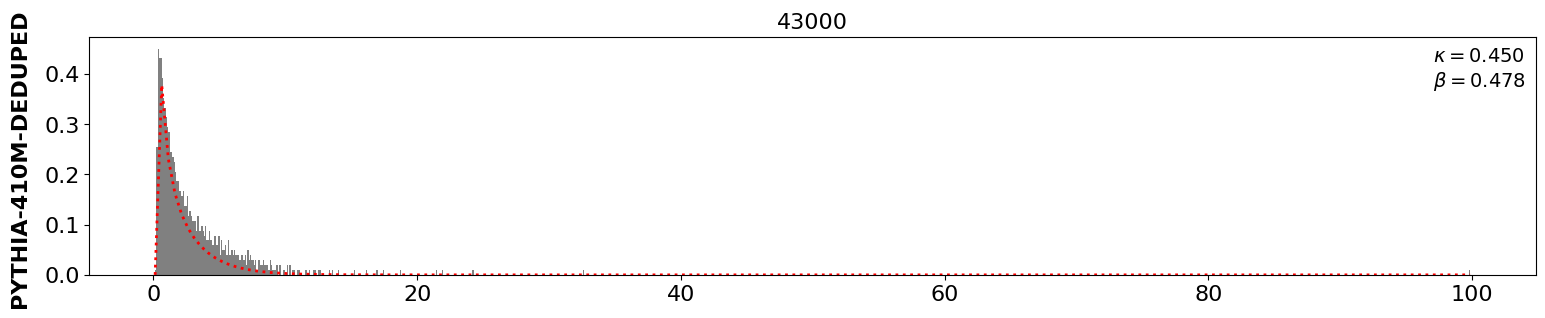

In [30]:
fit.kappa_opt[43000] = 0.45
fit.beta_opt[43000] = 0.06 / fit.tau_opt[43000] #0.75
fit.plot_esd(epoch_plot_interval=1, epochs_list=[43000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  3.07it/s]


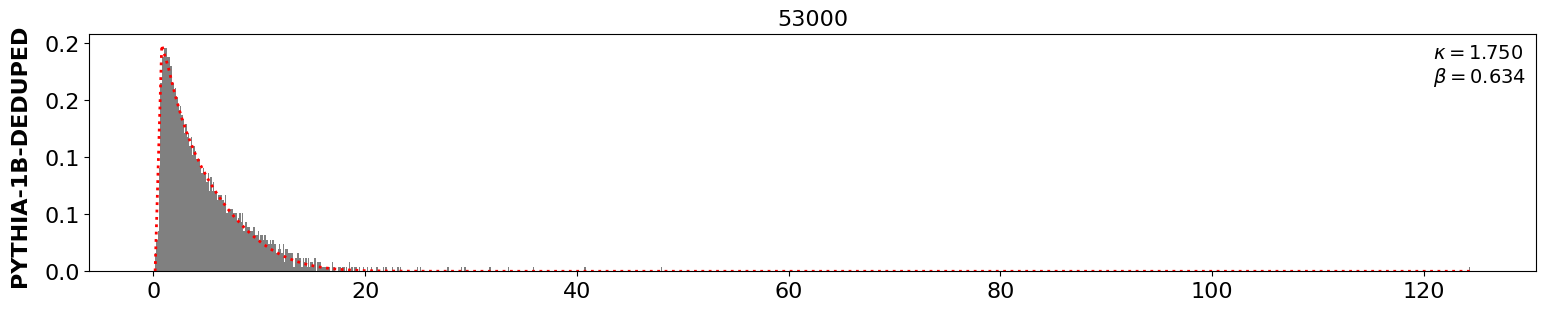

In [196]:
fit.kappa_opt[53000] = 1.75
fit.beta_opt[53000] = 0.1 / fit.tau_opt[53000] #0.8
fit.plot_esd(epoch_plot_interval=1, epochs_list=[53000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  1.37it/s]


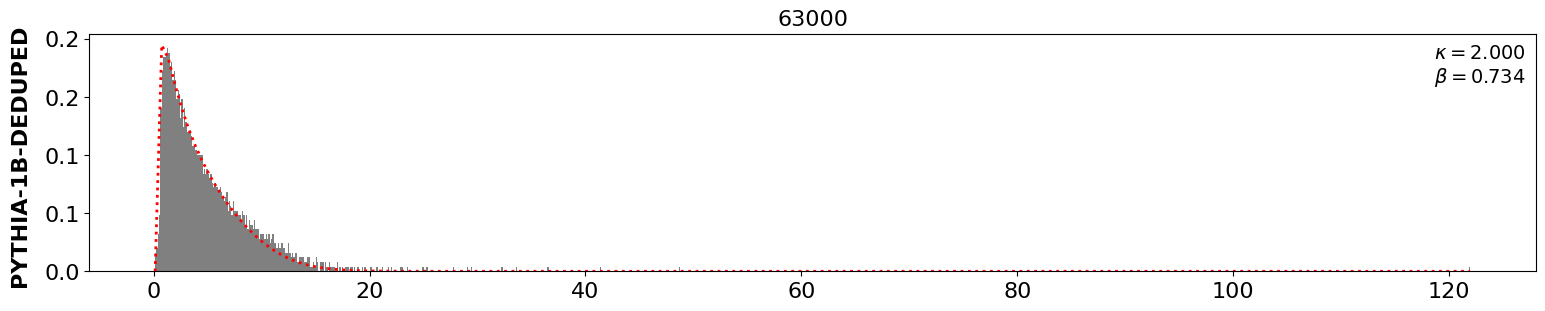

In [197]:
fit.kappa_opt[63000] = 2
fit.beta_opt[63000] = 0.1 / fit.tau_opt[63000] #0.7
fit.plot_esd(epoch_plot_interval=1, epochs_list=[63000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  1.80it/s]


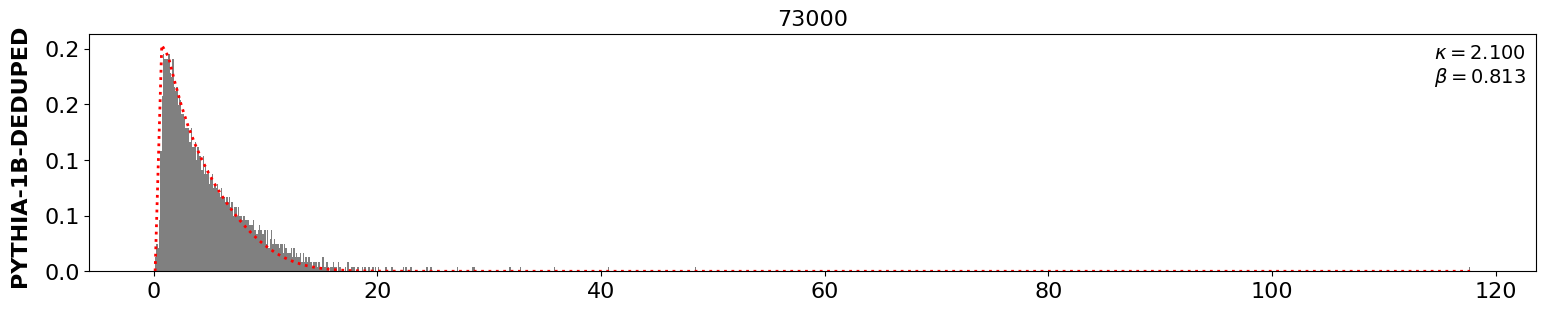

In [198]:
fit.kappa_opt[73000] = 2.1 # 2.2
fit.beta_opt[73000] = 0.1 / fit.tau_opt[73000] #0.8
fit.plot_esd(epoch_plot_interval=1, epochs_list=[73000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  5.38it/s]


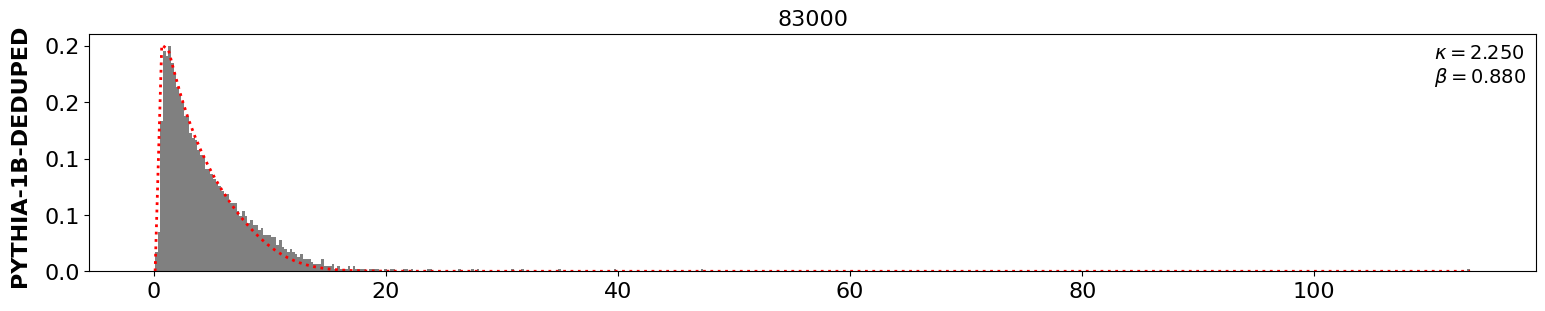

In [199]:
fit.kappa_opt[83000] = 2.25 # 1.8
fit.beta_opt[83000] = 0.1 / fit.tau_opt[83000] #0.7
fit.plot_esd(epoch_plot_interval=1, epochs_list=[83000], log_bins=False, n_bins=500, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  3.14it/s]


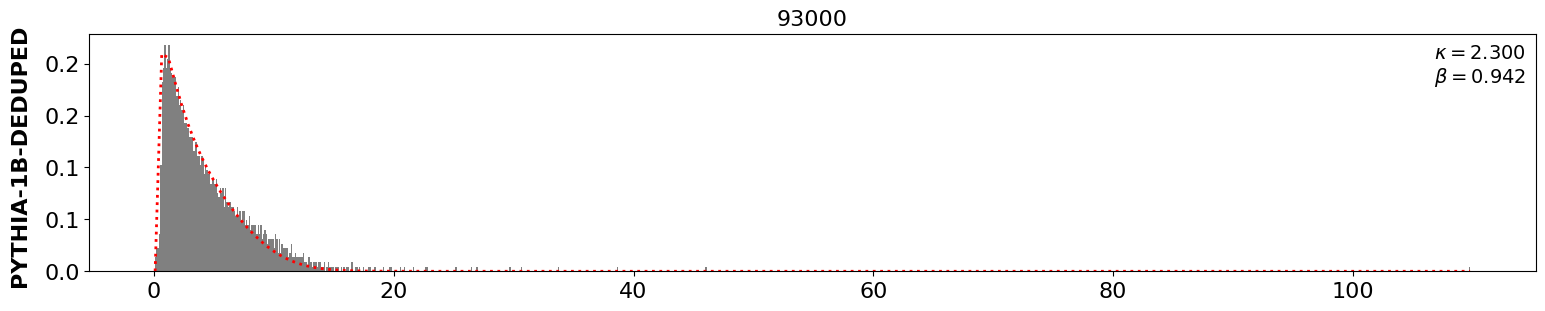

In [200]:
fit.kappa_opt[93000] = 2.3 # 1.8
fit.beta_opt[93000] = 0.1 / fit.tau_opt[93000] #0.7
fit.plot_esd(epoch_plot_interval=1, epochs_list=[93000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  2.08it/s]


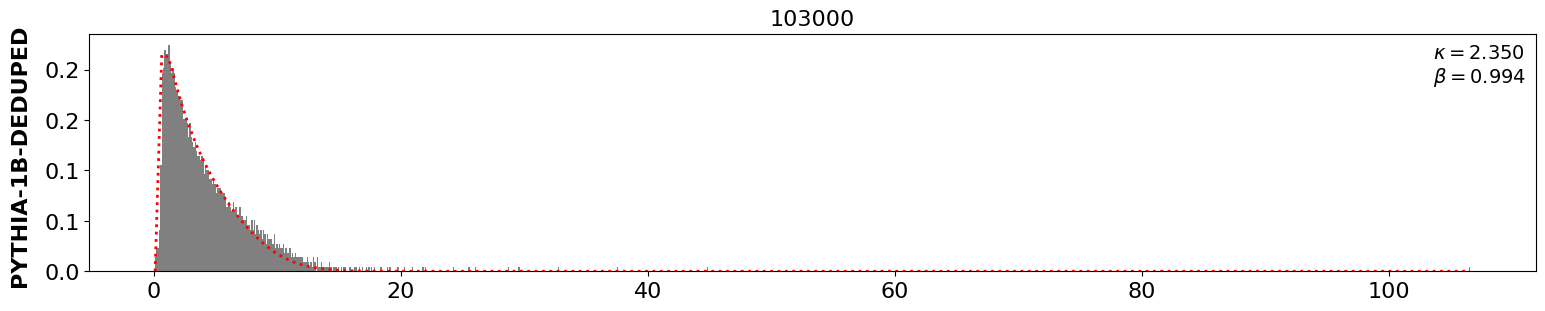

In [201]:
fit.kappa_opt[103000] = 2.35
fit.beta_opt[103000] = 0.1 / fit.tau_opt[103000] #0.7
fit.plot_esd(epoch_plot_interval=1, epochs_list=[103000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  3.10it/s]


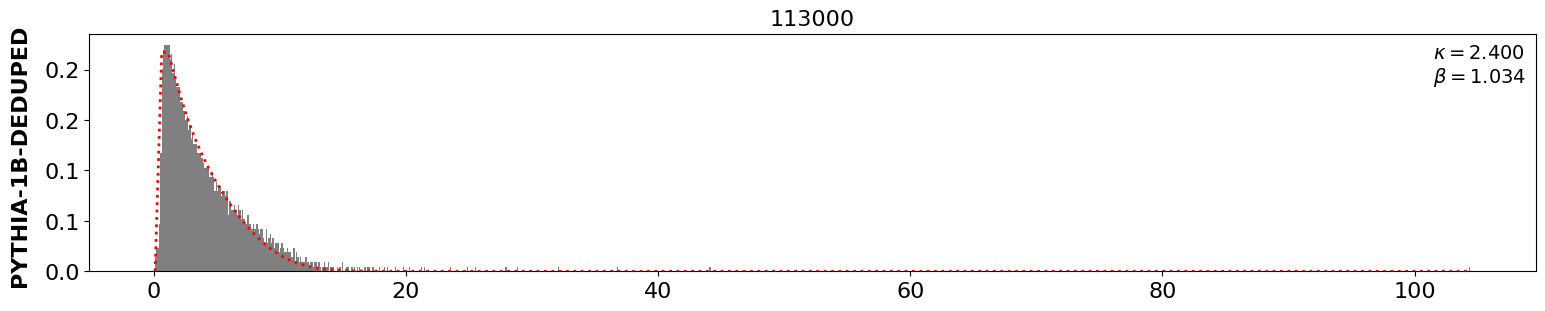

In [202]:
fit.kappa_opt[113000] = 2.4
fit.beta_opt[113000] = 0.1 / fit.tau_opt[113000] #1
fit.plot_esd(epoch_plot_interval=1, epochs_list=[113000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  2.93it/s]


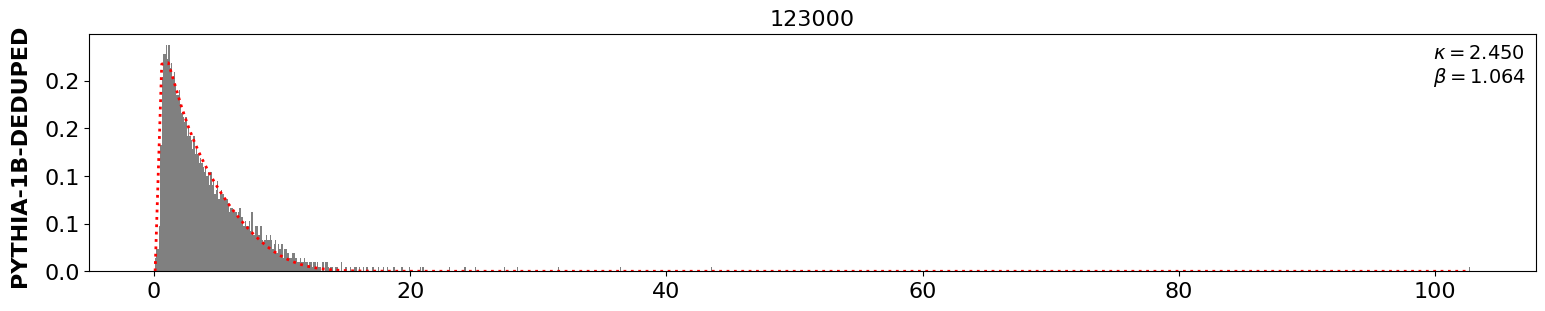

In [203]:
fit.kappa_opt[123000] = 2.45
fit.beta_opt[123000] = 0.1 / fit.tau_opt[123000] #1
fit.plot_esd(epoch_plot_interval=1, epochs_list=[123000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  1.97it/s]


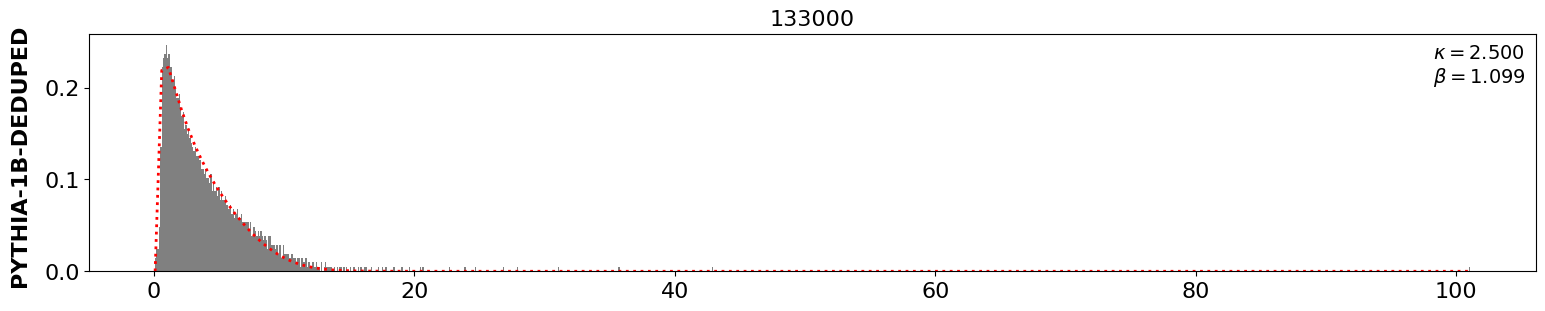

In [204]:
fit.kappa_opt[133000] = 2.5
fit.beta_opt[133000] = 0.1 / fit.tau_opt[133000] #1
fit.plot_esd(epoch_plot_interval=1, epochs_list=[133000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

1it [00:00,  2.96it/s]


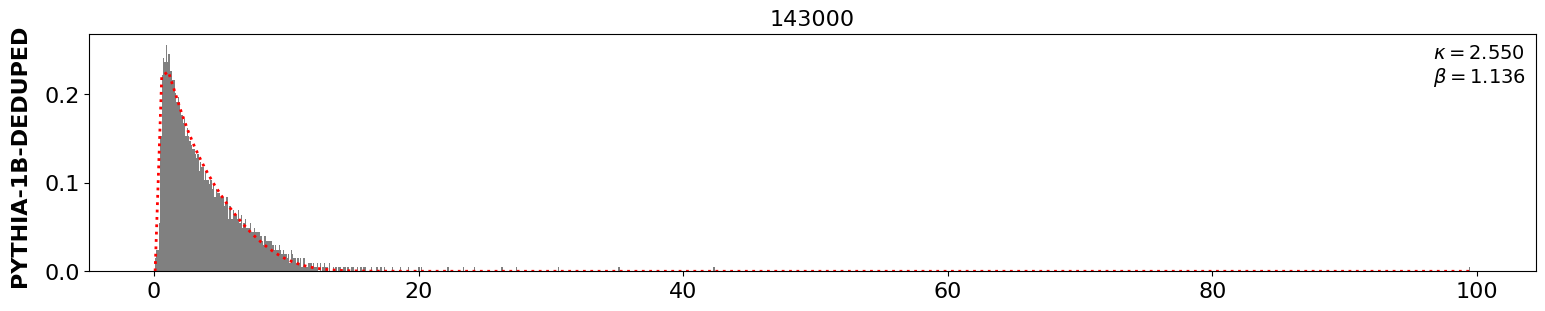

In [205]:
fit.kappa_opt[143000] = 2.55
fit.beta_opt[143000] = 0.1 / fit.tau_opt[143000] #1.3
fit.plot_esd(epoch_plot_interval=1, epochs_list=[143000], log_bins=False, n_bins=1000, title=True, fontsize=16, plot_htmp=True)

In [206]:
fit.save_htmp_fit()

'results/htmp/fits\\pythia-1b-deduped_pile_weight_b2m_QueryKey_layer0_fit.pt'

### Plot ESD

In [ ]:
fit.plot_esd(epoch_plot_interval=1, 
             epochs_list=[3000, 43000, 73000, 113000, 143000], 
             log_bins=False, 
             x_left = -2, 
             x_right = 30, 
             n_bins=500, 
             log_y=False, 
             title=True, 
             fontsize=18, 
             plot_power=False, 
             plot_htmp=True, 
             fig_width=15,
             fig_height_per_row=2,
             title_new='PYTHIA-1B'
)

### Free Energy vs. Acc

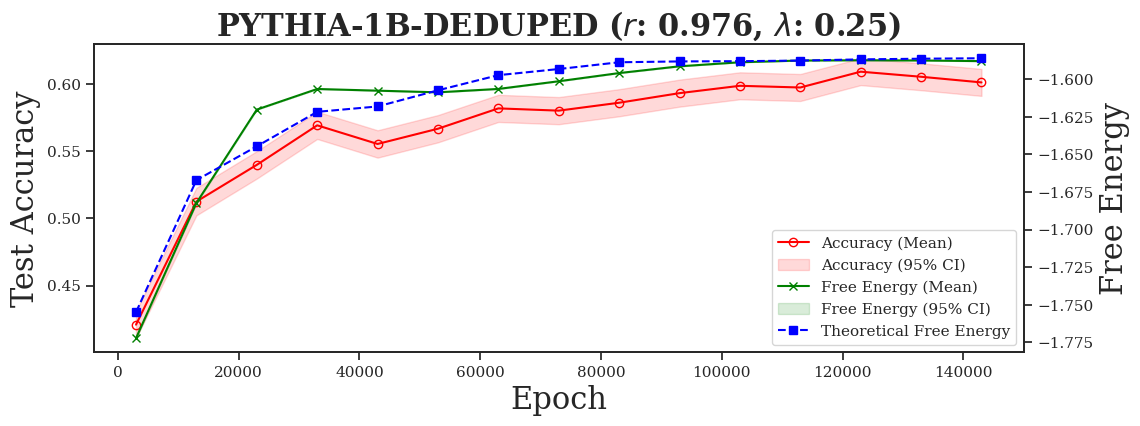

Correlation between Test Accuracy and -Free Energy: 0.976
Maximum Test Accuracy: 0.609 at Epoch=1.23e+05, Free Energy=-1.58730


In [3]:
x_var = 'epochs'
if x_var == 'epochs': 
    start_index = 0
elif x_var == 'kappa':
    start_index = 2

lambdas = {
    'pythia-1b-deduped': 0.25,
}

# Plot free energy fits
fit.compute_free_energy(lam=lambdas[fit.model], tau=0, weight_inverse=True)
fit.plot_test_vs_free(variable=x_var, neg_free='True', start_index=start_index, plot_theoretical_free=True, log_x=False, fig_height=4, fig_width=12,
                      task='arc_easy', shot='five-shot', single_plot=True, fontsize=22, texplot_enabled=True, title=True, tight_layout=False)

### Create plot of h_t and beta_t during training

In [22]:
import esdfit as esdfit
import numpy as np
from importlib import reload; reload(esdfit)
import matplotlib.pyplot as plt
import texplot
texplot.set_theme()


## Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(4, 5), sharex=True)
fontsize=16

# Have fewer x-ticks for clarity
ax1.set_xticks(steps[::4])

# Load fits
fit = esdfit.ESDFit(model='pythia-1b-deduped', dataset='pile', kernel='weight', batch_size='2m', subsample=False, file_dir = 'results/htmp/epoch',
                    weight_type='QueryKey',
                    layer=0)
fit.load_htmp_fit()
ax1 = fit.plot_kappa_beta_ratio_vs_epoch(
    start_index=0,
    title=False,
    fontsize=fontsize,
    texplot_enabled=True,
    show_fig=False,
    save_fig=False,
    axes=ax1,
    color_plot='green'
    
)
ax1.set_xlabel('')
print(f'c = {fit.beta_opt[fit.epoch_list[8]] * fit.tau_opt[fit.epoch_list[8]]}')
# ax1.set_title(r'$\tilde{h}$ Ratio vs. Epoch', fontsize=22, fontweight='bold')
ax1.set_ylabel(r'$\tilde{h}$', fontsize=fontsize)
ax1.legend(['$h_t$'])

# fig.savefig('figures/paper/pythia_1b_deduped_kappa_beta_ratio.pdf', bbox_inches='tight', format='pdf')
# plt.show()    

Plotting κ/β ratio vs. epoch on provided axes.
c = 0.1


Plotting κ/β ratio vs. epoch on provided axes.


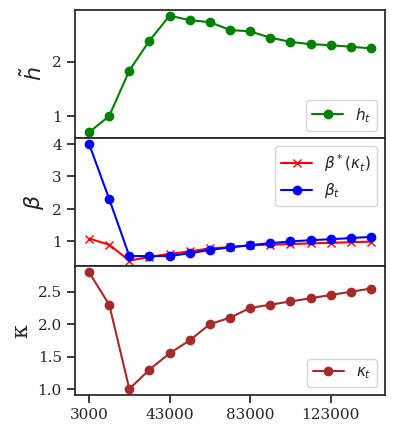

In [23]:
texplot.set_theme()
# fig, ax = plt.subplots(figsize=(8, 5))


kappas = np.array([fit.kappa_opt[epoch] for epoch in steps])
betas = np.array([fit.beta_opt[epoch] for epoch in steps])
gam = 0.33
lam = 0.25
c = 0.1
beta_opt = lam*c + lam*kappas / 2/gam


ax2.plot(steps, beta_opt, label=r'$\beta^*(\kappa_t)$', color='red', marker='x')
ax2.plot(steps, betas, label=r'$\beta_t$', color='blue', marker='o')
# ax2.set_title(r'$\beta$ vs. Epoch', fontsize=22, fontweight='bold')
ax2.legend()

# Have fewer x-ticks for clarity
ax2.set_xticks(steps[::4])

# ax2.set_xlabel('Epoch', fontsize=fontsize)
ax2.set_ylabel(r'$\beta$', fontsize=fontsize)



### Plot kappa vs epoch
ax3 = fit.plot_kappa_vs_epoch(
    start_index=0,
    title=False,
    fontsize=fontsize,
    texplot_enabled=True,
    show_fig=False,
    save_fig=False,
    axes=ax3,
    color_plot='brown'
    
)
ax3.set_xlabel('')

ax1.legend(['$h_t$'], loc='lower right')
ax3.legend(loc='lower right')
fig.subplots_adjust(hspace=0)
# fig.tight_layout()
plt.savefig('figures/paper/pythia_1b_deduped_parameters_vs_epoch.pdf', bbox_inches='tight', format='pdf')
plt.show()


### Trace and Log Det vs. Epochs

Log-Det at epoch 0: empirical=1.66
Min free energy epoch: 53000, min empirical free energy: 1.58


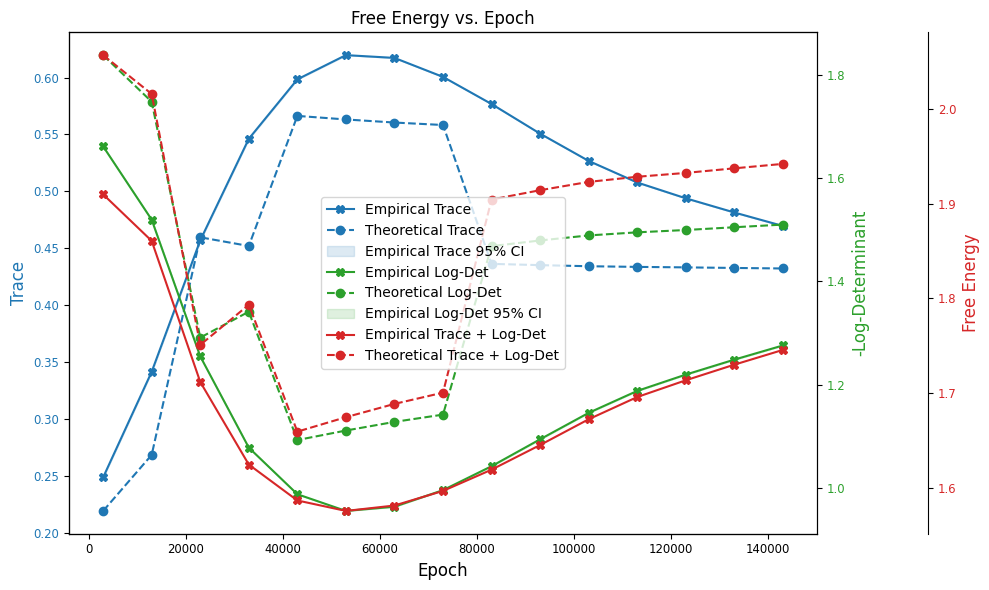

In [50]:
fit.compute_free_energy(lam=0.2, tau=0, weight_inverse=True)
fit.plot_trace_and_log_det(variable='epochs', plot_theoretical=True, start_index=0, plot_sum=True)

# # Free Energy - LLM

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import weightwatcher as ww

PyTorch is available but CUDA is not. Defaulting to SciPy for SVD
Import error , reetting to svd accurate methods


In [2]:
from helpers import load_pythia_eval_metric

def get_test_acc(model, task, shot = 'zero-shot'):
    model_size = model.split('-')[1]  # Extract size from model name
    dict = load_pythia_eval_metric(
                    model_size=model_size,
                    task=task,
                    metric='acc',
                    evals_root='evals',
                    shot=shot,
                    deduped=True,
                )
    return list(dict['value'])[-1]

In [3]:
def mean_bfe(e, lam=1, n = 1000, jitter=1e-2):
    fro_norm = torch.sum(e + jitter).item() / n
    logdet_term = torch.sum(torch.log((e + jitter))).item() / n
    free_energy = lam/2 * fro_norm - 0.5 * logdet_term + 1/2 * np.log(2 * np.pi / lam)
    return free_energy

In [4]:
def mean_bfe_unnormalized(e, lam=1, n = 1000, jitter=1e-2):
    fro_norm = torch.sum(e + jitter).item() / n
    logdet_term = torch.sum(torch.log((e + jitter)/lam)).item() / n
    free_energy = lam/2 * fro_norm - 0.5 * logdet_term
    return free_energy

In [5]:
def optim_lam(e, lam_min=1e-3, lam_max=1e3, num_lams=100, jitter=1e-2, n=1000):
    lams = np.logspace(np.log10(lam_min), np.log10(lam_max), num_lams)
    free_energies = [mean_bfe(e, lam, n, jitter=jitter) for lam in lams]
    optimal_lam = lams[np.argmin(free_energies)]
    optimal_free_energy = min(free_energies)
    return optimal_lam, optimal_free_energy

In [6]:
models = [
    "pythia-70m-deduped", 
    "pythia-160m-deduped", 
    "pythia-410m-deduped", 
    "pythia-1b-deduped",
    "pythia-1.4b-deduped",
    "pythia-2.8b-deduped",
    "pythia-6.9b-deduped",
    "pythia-12b-deduped"
]

In [42]:
import weightwatcher.WW_powerlaw as wwp
import weightwatcher.weightwatcher as wwmod

from weightwatcher.constants import TRUNCATED_POWER_LAW, POWERLAW_PACKAGE
import powerlaw

def compute_weightwatcher_metrics(res_dict, all_weights=True):

    weight_types = ['EmbedOut', 'Dense', 'QueryKey'] if all_weights else ['EmbedOut']
    lfns = []
    linfs = []
    weight_alphas = []
    alpha_norms = []
    alphas = []
    lambdas = []

    for weight_type in weight_types:
        eigenvalue_set = res_dict[weight_type]
        indices = [0] if weight_type == 'EmbedOut' else eigenvalue_set.keys()  # Assuming keys are layer identifiers
        for idx in indices:
            evals = eigenvalue_set['eigvals'] if weight_type == 'EmbedOut' else eigenvalue_set[idx]['eigvals']
            evals = np.asarray(evals)
            evals = evals[np.isfinite(evals)]
            evals = np.sort(evals[evals > 0])

            # Patch WeightWatcher's pl_fit to be compatible with powerlaw==2.0.0
            def patched_pl_fit(
                data=None,
                xmin=None,
                xmax=None,
                verbose=False,
                distribution="power_law",
                pl_package="powerlaw",
            ):
                return powerlaw.Fit(
                    data,
                    xmin=xmin,
                    xmax=xmax,
                    discrete=False,
                    verbose=verbose,
                )


            wwp.pl_fit = patched_pl_fit
            wwmod.pl_fit = patched_pl_fit


            evals = np.asarray(evals, dtype=float)
            evals = np.sort(evals[np.isfinite(evals) & (evals > 0)])

            watcher = ww.WeightWatcher()

            out = watcher.fit_powerlaw(
                evals,
                fit_type=TRUNCATED_POWER_LAW,
                pl_package=POWERLAW_PACKAGE,
                plot=False,
                savefig=False,
                layer_name="my_layer",
                layer_id=0,
            )

            alpha, Lambda, xmin, xmax, D, sigma, num_pl_spikes, num_fingers, raw_alpha, status, warning = out


            lfns.append(np.log10(np.sum(evals)))
            linfs.append(np.log10(evals.max().item()))
            weight_alphas.append(alpha * evals.max().item())
            alpha_norms.append(alpha * lfns[-1])
            alphas.append(alpha)
            lambdas.append(Lambda)
    
    return {
        'log_norm': np.mean(np.array(lfns)),
        'log_spectral_norm': np.mean(np.array(linfs)),
        'alpha_weighted': np.mean(np.array(weight_alphas)),
        'log_alpha_norm': np.mean(np.array(alpha_norms)),
        'alpha': np.mean(np.array(alphas)),
        'lambda': np.mean(np.array(lambdas)),
    }
    

100%|██████████| 8/8 [05:22<00:00, 40.37s/it]

Pearson correlation (Arc Easy Zero-Shot): -0.97
Pearson correlation (Arc Challenge Zero-Shot): -0.91
Pearson correlation (Arc Easy Five-Shot): -0.97
Pearson correlation (Arc Challenge Five-Shot): -0.93


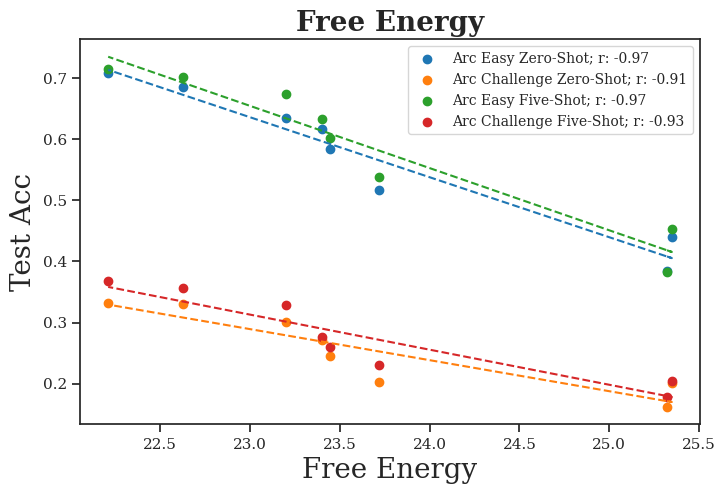

Pearson correlation (Arc Easy Zero-Shot): 0.92
Pearson correlation (Arc Challenge Zero-Shot): 0.95
Pearson correlation (Arc Easy Five-Shot): 0.90
Pearson correlation (Arc Challenge Five-Shot): 0.95


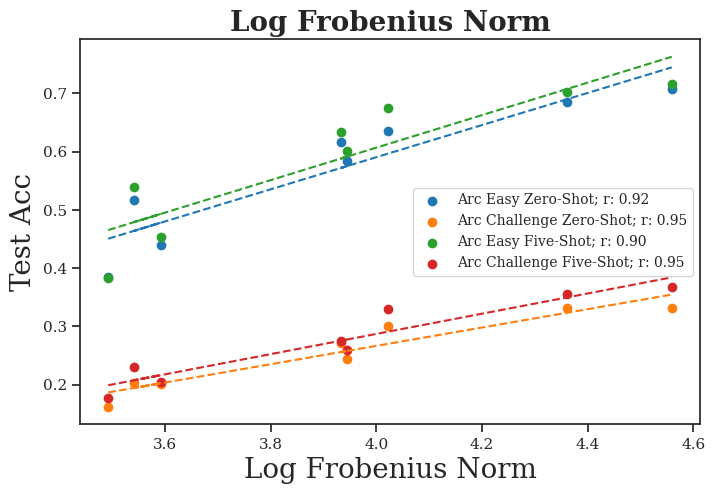

Pearson correlation (Arc Easy Zero-Shot): 0.62
Pearson correlation (Arc Challenge Zero-Shot): 0.72
Pearson correlation (Arc Easy Five-Shot): 0.57
Pearson correlation (Arc Challenge Five-Shot): 0.71


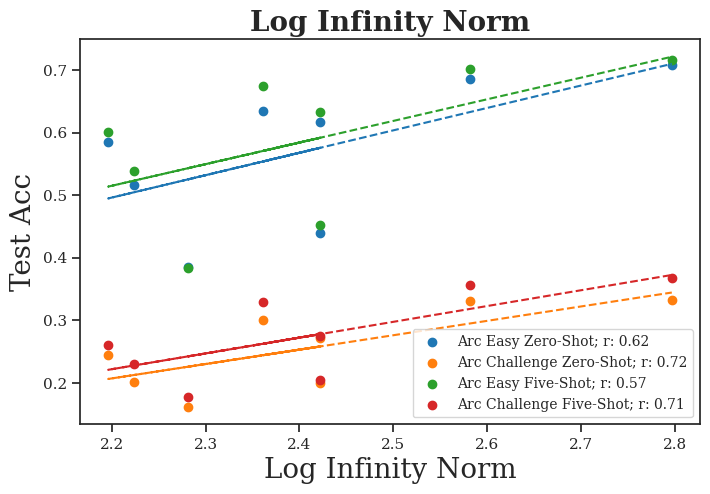

Pearson correlation (Arc Easy Zero-Shot): -0.87
Pearson correlation (Arc Challenge Zero-Shot): -0.75
Pearson correlation (Arc Easy Five-Shot): -0.89
Pearson correlation (Arc Challenge Five-Shot): -0.76


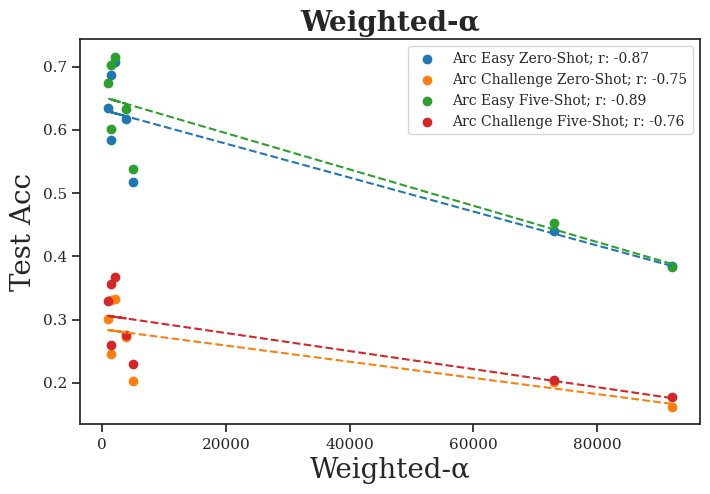

Pearson correlation (Arc Easy Zero-Shot): 0.96
Pearson correlation (Arc Challenge Zero-Shot): 0.96
Pearson correlation (Arc Easy Five-Shot): 0.95
Pearson correlation (Arc Challenge Five-Shot): 0.96


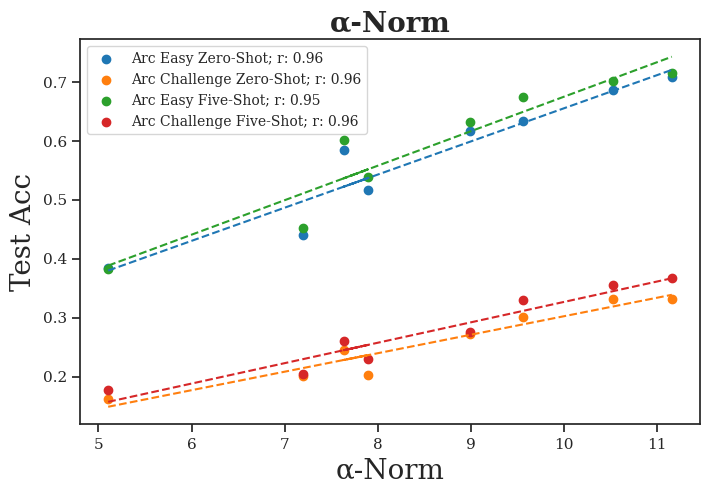

Pearson correlation (Arc Easy Zero-Shot): 0.86
Pearson correlation (Arc Challenge Zero-Shot): 0.84
Pearson correlation (Arc Easy Five-Shot): 0.88
Pearson correlation (Arc Challenge Five-Shot): 0.84


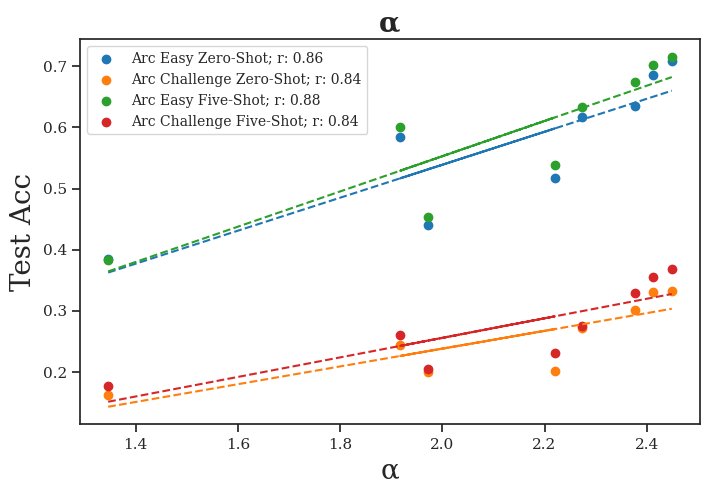

Pearson correlation (Arc Easy Zero-Shot): -0.89
Pearson correlation (Arc Challenge Zero-Shot): -0.86
Pearson correlation (Arc Easy Five-Shot): -0.91
Pearson correlation (Arc Challenge Five-Shot): -0.84


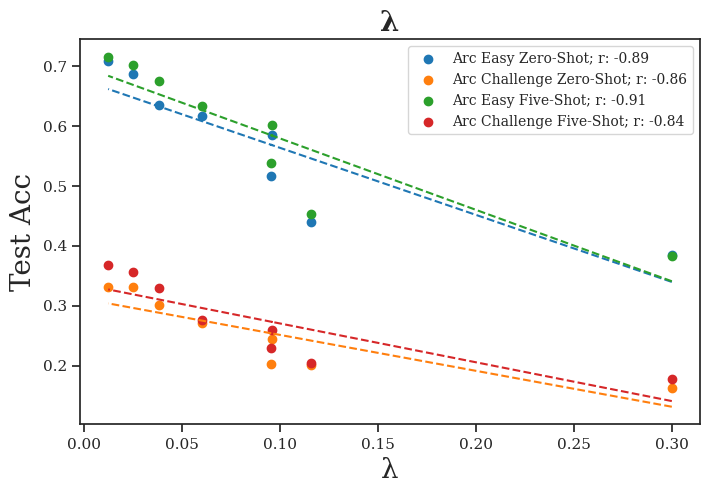

In [43]:
import htmp.htmp as htmp; from importlib import reload; reload(htmp); import powerlaw; import weightwatcher as ww; import texplot; texplot.set_theme()
import tqdm

fig_height = 5; fig_width = 8; font_size = 20; legend_size = 10

step = 143000
plot_all_metrics = True
all_weights = True
# Test Accs
accs = {
    'Arc Easy Zero-Shot': [],
    'Arc Challenge Zero-Shot': [],
    'Arc Easy Five-Shot': [],
    'Arc Challenge Five-Shot': [],
}

# Metrics
metrics = {
    'Free Energy': [],
    'Log Frobenius Norm': [],
    'Log Infinity Norm': [],
    'Weighted-α': [],
    'α-Norm': [],
    'α': [],
    'λ': [],

}

for model in tqdm.tqdm(models):
    res_dict = torch.load(f'results\\htmp\\epoch\\{model}_pile_b2m_{step}_0.pt', weights_only=False)
    e = torch.from_numpy(res_dict['EmbedOut']['eigvals'])
    # e = torch.from_numpy(res_dict['QueryKey'][0]['eigvals'])
    e = torch.cat([e, torch.zeros(50304 - len(e))])  # Pad with zeros to length 10000
    # print(f'Model: {model}, number of eigenvalues: {len(e)}')
    optimal_lam, optimal_free_energy = optim_lam(e, n=len(e), jitter=1e-20, num_lams=100)
    # print(optimal_lam)
    metrics['Free Energy'].append(optimal_free_energy)

    # Compute weightwatcher metrics
    ww_metrics = compute_weightwatcher_metrics(res_dict, all_weights=all_weights)

    metrics['Log Frobenius Norm'].append(ww_metrics['log_norm'])
    metrics['Log Infinity Norm'].append(ww_metrics['log_spectral_norm'])
    metrics['Weighted-α'].append(ww_metrics['alpha_weighted'])
    metrics['α-Norm'].append(ww_metrics['log_alpha_norm'])
    metrics['α'].append(ww_metrics['alpha'])
    metrics['λ'].append(ww_metrics['lambda'])

    accs['Arc Easy Zero-Shot'].append(get_test_acc(model, "arc_easy", shot='zero-shot'))
    accs['Arc Challenge Zero-Shot'].append(get_test_acc(model, "arc_challenge", shot='zero-shot'))
    accs['Arc Easy Five-Shot'].append(get_test_acc(model, "arc_easy", shot='five-shot'))
    accs['Arc Challenge Five-Shot'].append(get_test_acc(model, "arc_challenge", shot='five-shot'))
    # print(f'Model: {model}, Optimal lambda: {optimal_lam}, Optimal free energy: {optimal_free_energy}, test acc (easy): {get_test_acc(model, "arc_easy")}, test acc (challenge): {get_test_acc(model, "arc_challenge")} ')


plot_metrics = metrics.keys() if plot_all_metrics else ['Free Energy']

# Plot metrics
for metric in plot_metrics:
    plt.figure(figsize=(8, 5))

    for acc_key in accs.keys():
        corr = np.corrcoef(metrics[metric], accs[acc_key])[0, 1]
        plt.scatter(metrics[metric], accs[acc_key], marker='o', label=f'{acc_key}; r: {corr:.2f}')
        m, b = np.polyfit(metrics[metric], accs[acc_key], 1)
        plt.plot(metrics[metric], m*np.array(metrics[metric]) + b, linestyle='--')
        print(f'Pearson correlation ({acc_key}): {corr:.2f}')

    title_f = f'{metric}' if plot_all_metrics else 'LLM'
    plt.title(title_f, fontsize=font_size, fontweight='bold')
    plt.xlabel(metric, fontsize=font_size)
    plt.ylabel('Test Acc', fontsize=font_size)
    plt.legend(fontsize=legend_size)
    
    f_ww = 'all_weights' if all_weights else 'final_layer_weights'

    save_f = f'free_energy_vs_acc_llm.pdf' if not plot_all_metrics else f'{metric}_{f_ww}_vs_acc_llm.pdf'
    plt.savefig('figures/paper/' + save_f, bbox_inches='tight', format='pdf')
    plt.show()

# Moonlight / MoonShot AI Checkpoints

## Save models in correct format

In [1]:
from helpers import save_all_moonlight_checkpoint_summaries

paths = save_all_moonlight_checkpoint_summaries()

## ESD Fit

In [10]:
import esdfit as esdfit
import torch
import numpy as np
from importlib import reload; reload(esdfit)
from helpers import list_pythia_eval_steps

# Load fits
model = "moonlight_adam"
fit = esdfit.ESDFit(model=model, 
                    dataset='openwebtext', 
                    kernel='weight', 
                    batch_size='2m', 
                    subsample=False, 
                    file_dir = 'results/htmp/epoch',
                    weight_type='KeyValue',
                    layer=1)
fit.load_htmp_fit()

True

In [18]:
fit.fit_htmp(search_method='grid', 
             shared_beta_grid=False, 
             beta_from_tau=False,
             n_eval=100,
             kappa_min=0.01, 
             kappa_max=1, 
             num_kappas=20, 
             kappa_log_scale=False,
             beta_min=0.001, 
             beta_max = 1, 
             num_betas = 20, 
             beta_log_scale=False,
             tau_min=0,
             tau_max=0,
             num_taus=1,
             epochs_list=None,
             moment_penalty_weight=0,
             verbose=True,
             extra_verbose=True,
             shared_tau_grid=False,
             stieltjes=False,
             vectorized_grid=True,
             save_fit=True)

Loading eigenvalues...
Fitting HTMP parameters for 7 epochs using grid search...


c:\Users\s4531973\Documents\PhD\Code\logdeterminant\helpers.py:1283: RuntimeWarning: divide by zero encountered in log
  return const + a*np.log(y) - y - _log_neg_hypu(b, a, y)


Best grid point: kappa=0.1142, beta=0.5268, distance=0.113055
Fitting HTMP for Epoch: 6000, κ*: 0.114, β*: 0.527, τ*: 0.043, ||.||ₚ*: 0.113
Best grid point: kappa=0.1142, beta=0.1062, distance=0.143103
Fitting HTMP for Epoch: 12000, κ*: 0.114, β*: 0.106, τ*: 0.139, ||.||ₚ*: 0.143
Best grid point: kappa=0.06211, beta=0.05358, distance=0.110406
Fitting HTMP for Epoch: 18000, κ*: 0.062, β*: 0.054, τ*: 0.156, ||.||ₚ*: 0.110
Best grid point: kappa=0.06211, beta=0.05358, distance=0.155699
Fitting HTMP for Epoch: 24000, κ*: 0.062, β*: 0.054, τ*: 0.171, ||.||ₚ*: 0.156
Best grid point: kappa=0.06211, beta=0.05358, distance=0.192459
Fitting HTMP for Epoch: 30000, κ*: 0.062, β*: 0.054, τ*: 0.177, ||.||ₚ*: 0.192
Best grid point: kappa=0.06211, beta=0.05358, distance=0.209873
Fitting HTMP for Epoch: 36000, κ*: 0.062, β*: 0.054, τ*: 0.159, ||.||ₚ*: 0.210
Best grid point: kappa=0.06211, beta=0.05358, distance=0.207424
Fitting HTMP for Epoch: 42000, κ*: 0.062, β*: 0.054, τ*: 0.155, ||.||ₚ*: 0.207
Save

c:\Users\s4531973\Documents\PhD\Code\logdeterminant\esdfit.py:1230: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  f.subplots_adjust(hspace=0.4, top=0.8, left=0.14)
7it [00:00, 10.79it/s]


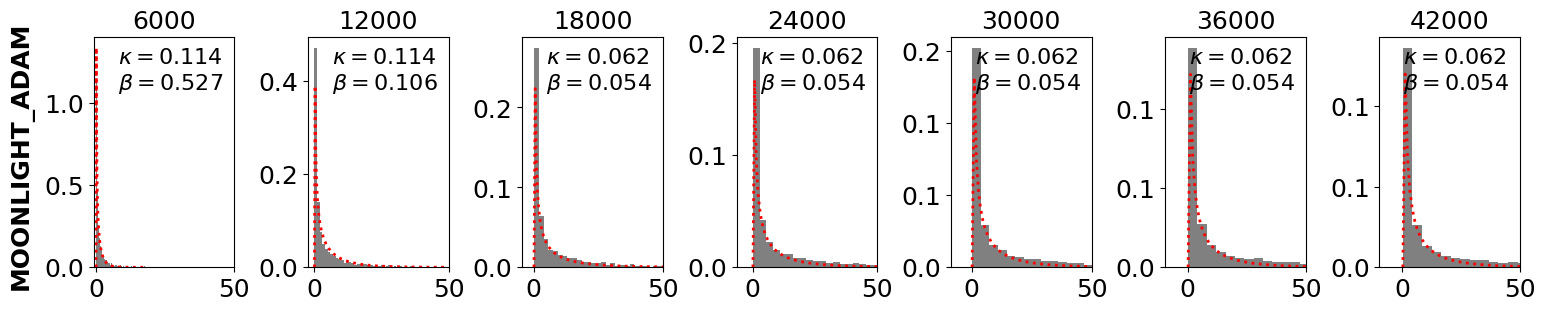

In [20]:
fit.plot_esd(
    epoch_plot_interval=1,
    num_plots_per_row=7,
    epochs_list=None,
    plot_htmp=True,
    log_bins=False,
    n_bins=50,
    title=True,
    fontsize=18,
    x_right=50
)

In [95]:
fit.save_htmp_fit()

'results/htmp/fits\\moonlight_muon_openwebtext_weight_b2m_KeyValue_layer25_fit.pt'

c:\Users\s4531973\Documents\PhD\Code\logdeterminant\esdfit.py:1230: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  f.subplots_adjust(hspace=0.4, top=0.8, left=0.14)
1it [00:00, 11.55it/s]


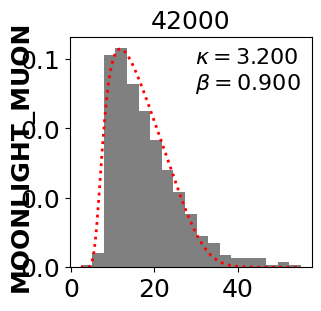

In [ ]:
fit.kappa_opt[24000] = 3.2
fit.beta_opt[24000] = 0.9
fit.plot_esd(
    epoch_plot_interval=1,
    num_plots_per_row=7,
    epochs_list=[24000],
    plot_htmp=True,
    log_bins=False,
    n_bins=20,
    title=True,
    fontsize=18,
    fig_width=3
)

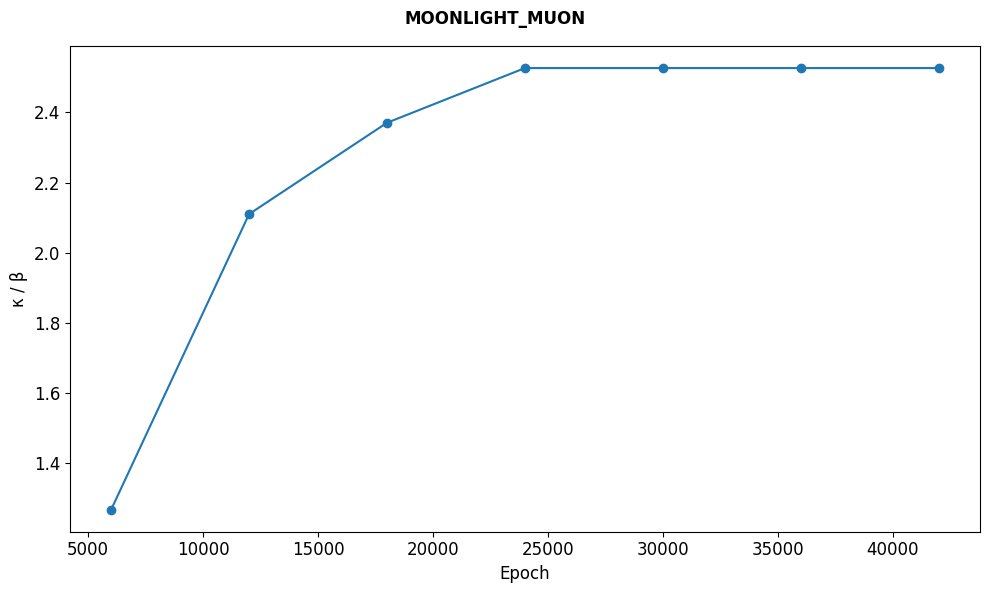

In [11]:
fit.plot_kappa_beta_ratio_vs_epoch()

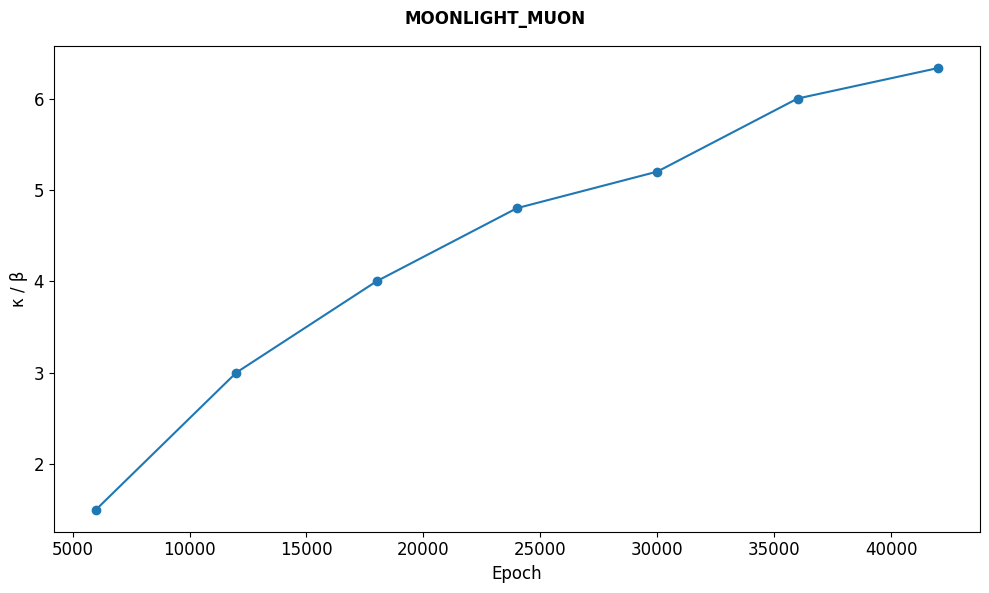

In [18]:
fit.plot_kappa_beta_ratio_vs_epoch()